In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For time series and forecasting
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.statespace.exponential_smoothing import ExponentialSmoothing as ETSStateSpace
import statsmodels.api as sm
import pmdarima as pm
from scipy.stats import boxcox
from scipy.special import inv_boxcox

In [6]:
df = pd.read_csv('auscafe_1982_2017.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df

,Cafe_Expenditure
Month,
1982-04-01,0.3424
1982-05-01,0.3421
1982-06-01,0.3287
1982-07-01,0.3385
1982-08-01,0.3315
...,...
2017-05-01,3.5986
2017-06-01,3.5442
2017-07-01,3.6981


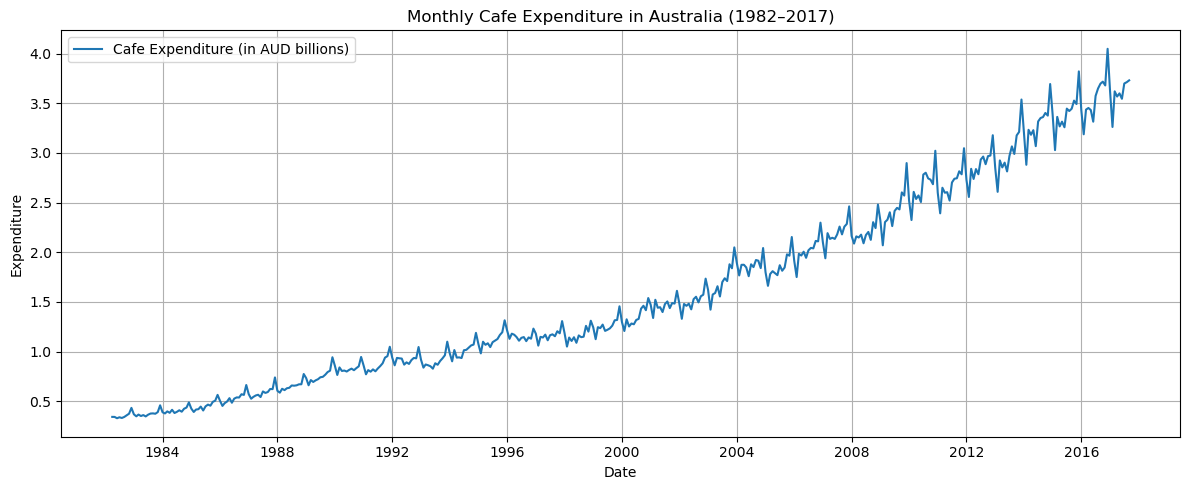

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df, label='Cafe Expenditure (in AUD billions)')
plt.title("Monthly Cafe Expenditure in Australia (1982–2017)")
plt.xlabel("Date")
plt.ylabel("Expenditure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1. What is the length of the test set?

In [8]:
# Create training and test sets
train = df['1995-02-01':'2014-12-01']
test = df['2015-01-01':'2017-09-01']

# Check the lengths
print("Training set length:", len(train))
print("Test set length:", len(test))

Training set length: 239
Test set length: 33


2. Box-Cox λ parameter (based on training set)

In [12]:
# Automatic selection of Box-Cox λ parameter using the training set
train_values = train['Cafe_Expenditure'].values
transformed, fitted_lambda = boxcox(train_values)
print("Optimal Box-Cox λ parameter:", fitted_lambda)

Optimal Box-Cox λ parameter: -0.08978230013227309


3. Seasonal subseries plot

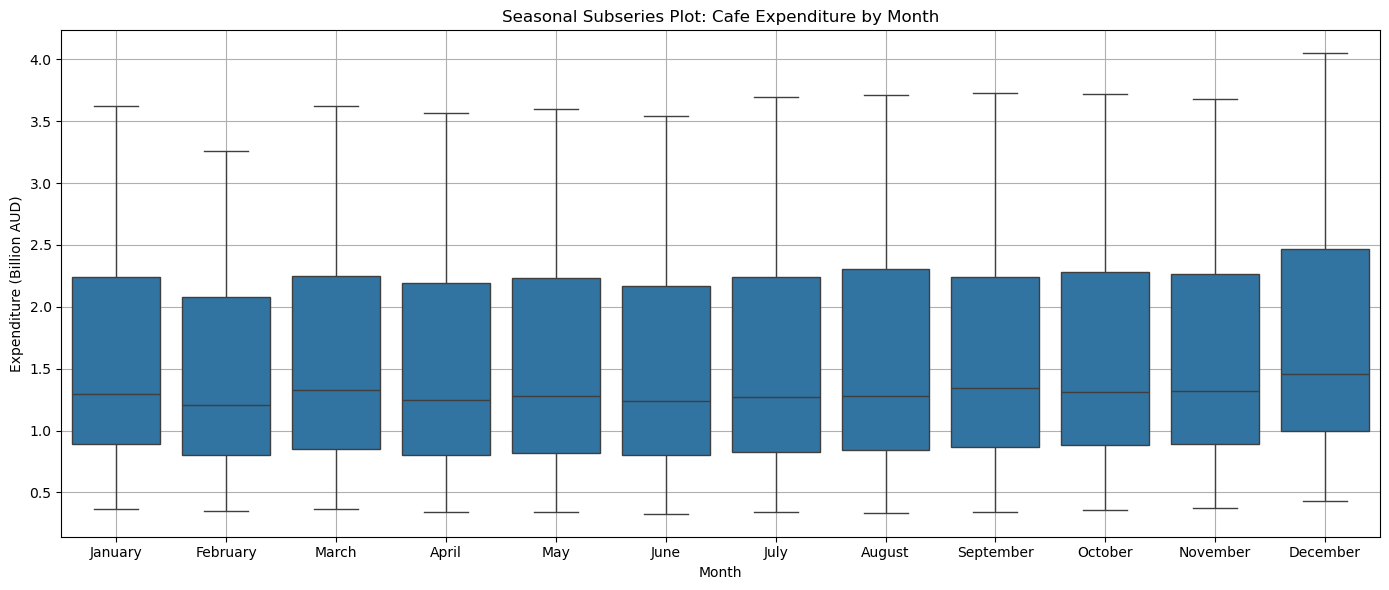

In [15]:
# Add readable month names
df['Month_Name'] = df.index.month_name()

# Plot using month names in calendar order
plt.figure(figsize=(14, 6))
sns.boxplot(x='Month_Name', y='Cafe_Expenditure', data=df,
            order=['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December'])
plt.title('Seasonal Subseries Plot: Cafe Expenditure by Month')
plt.xlabel('Month')
plt.ylabel('Expenditure (Billion AUD)')
plt.grid(True)
plt.tight_layout()
plt.show()

The seasonal subseries plot reveals strong and consistent seasonal patterns in monthly cafe expenditures in Australia over the period April 1982 to September 2017:
- December consistently shows the highest median and upper-range values, indicating a seasonal peak in spending, likely driven by the holiday season and end-of-year gatherings.
- February exhibits lower median values and a smaller spread, suggesting a post-holiday decline in consumer activity.
- Other months like January, March, and May also show moderate variability, but their medians are notably lower than December.
- The boxplots show distinct distributions for each month, confirming that monthly expenditure patterns are not uniform and vary systematically throughout the year.
- The relatively consistent medians across the same months in different years indicate that the seasonal effects are stable and recurring, not random.

4. Generate forecasts with Holt-Winters multiplicative method

In [18]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np

# Fit Holt-Winters multiplicative model
m1 = ExponentialSmoothing(
    train['Cafe_Expenditure'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit(optimized=True)

# Estimated smoothing parameters
print("Estimated smoothing parameters:")
print(f"alpha: {m1.model.params['smoothing_level']:.4f}")
print(f"beta: {m1.model.params['smoothing_trend']:.4f}")
print(f"gamma: {m1.model.params['smoothing_seasonal']:.4f}")

# Forecast 33 months ahead
forecast = m1.forecast(len(test))

# Forecast for January 2015
jan2015_forecast = forecast.iloc[0]
print(f"\nForecast for January 2015: {jan2015_forecast:.4f}")
# 95% PI not available directly for HW in statsmodels

# RMSE
rmse = np.sqrt(mean_squared_error(test['Cafe_Expenditure'], forecast))
print(f"Test set RMSE: {rmse:.4f}")

# Ljung-Box test on residuals
residuals = train['Cafe_Expenditure'] - m1.fittedvalues
lb_test = acorr_ljungbox(residuals, lags=[12], return_df=True)
print("\nLjung-Box test (lag 12):")
print(lb_test)

Estimated smoothing parameters:
alpha: 0.6856
beta: 0.0000
gamma: 0.0000

Forecast for January 2015: 3.3223
Test set RMSE: 0.0634

Ljung-Box test (lag 12):
     lb_stat  lb_pvalue
12  14.15701   0.290795


c:\ProgramData\anaconda3\envs\py\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


5. Generate an ETS model using the automated ets procedure, using log transformed data and bias adjustment

In [ ]:
# Log-transform training data
log_train = np.log(train['Cafe_Expenditure'])

# Fit ETS model (automatic selection)
m2 = ETSModel(
    log_train,
    error='add',
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Forecast (log scale)
log_forecast = m2.forecast(steps=len(test))

# Invert log (with bias adjustment: exp + 0.5 * sigma^2)
sigma2 = np.var(m2.resid, ddof=1)  # Residual variance
forecast_m2 = np.exp(log_forecast + 0.5 * sigma2)

# RMSE
rmse_m2 = np.sqrt(mean_squared_error(test['Cafe_Expenditure'], forecast_m2))
print(f"RMSE on test set: {rmse_m2:.4f}")

# Model summary
print("\nEstimated ETS model form:")
print(f"ETS({m2.model.error},{m2.model.trend},{m2.model.seasonal})")

print("\nState space parameter estimates:")
print(m2.params)

# Ljung-Box test
residuals_m2 = m2.resid
lb_test_m2 = acorr_ljungbox(residuals_m2, lags=[12], return_df=True)
print("\nLjung-Box test (lag 12):")
print(lb_test_m2)

RMSE on test set: 0.1116

Estimated ETS model form:
ETS(add,add,add)

State space parameter estimates:
0     0.667132
1     0.000067
2     0.000033
3    -0.019104
4     0.004743
5     0.094668
6     0.193929
7     0.104878
8     0.119270
9     0.082066
10    0.093252
11    0.088390
12    0.039091
13    0.079811
14    0.070036
15    0.091401
16    0.000000
dtype: float64

Ljung-Box test (lag 12):
      lb_stat  lb_pvalue
12  11.477422   0.488506


c:\ProgramData\anaconda3\envs\py\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


6. Generate forecasts using the auto.arima procedure, on the log transformed data with bias adjustment

In [ ]:
# Log-transform training data
log_train = np.log(train['Cafe_Expenditure'])

# Fit auto_arima
m3 = pm.auto_arima(
    log_train,
    seasonal=True,
    m=12,
    stepwise=True,
    approximation=True,
    suppress_warnings=True,
    trace=True
)

# Forecast on log scale
log_forecast = m3.predict(n_periods=len(test))

# Bias adjustment
resid_var = np.var(m3.resid(), ddof=1)
forecast_m3 = np.exp(log_forecast + 0.5 * resid_var)

# RMSE on test set
rmse_m3 = np.sqrt(mean_squared_error(test['Cafe_Expenditure'], forecast_m3))
print(f"RMSE on test set: {rmse_m3:.4f}")

# Model summary
print("\nARIMA model summary:")
print(m3.summary())

# Ljung-Box test on residuals
lb_test_m3 = acorr_ljungbox(m3.resid(), lags=[12], return_df=True)
print("\nLjung-Box test (lag 12):")
print(lb_test_m3)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-1062.907, Time=1.02 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-641.728, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-991.370, Time=0.46 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-825.938, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-641.836, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=-824.230, Time=0.65 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=-989.572, Time=0.93 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=-1064.885, Time=1.74 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=-1023.789, Time=1.48 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=1.82 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=-1023.563, Time=1.51 sec
 ARIMA(1,1,2)(2,0,1)[12] intercept   : AIC=-1068.128, Time=1.23 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=-1067.758, Time=0.69 sec
 ARIMA(1,1,2)(2,0,0)[12] intercept   : AIC=-1030.292, Time=1.10 sec
 ARIMA(1,1,2)(2,0

Final Model Selection (Q7)

- Model m2 (ETS) achieved the lowest RMSE (0.1116) and a Ljung-Box p-value of 0.4885, indicating well-behaved residuals.  
- Model m3 (ARIMA) had higher RMSE (0.1589) and similar residual diagnostics (p = 0.4787).

Final model selected: **m2 (ETS)** — due to better predictive accuracy and equally good residual behavior.